<a href="https://colab.research.google.com/github/NauaneLopes/Citologia_Oral/blob/main/MODELOS_APLICADOS_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
! pip install scipy tqdm

In [ ]:
import os
import tarfile
import scipy.io
import numpy as np
from PIL import Image
from tqdm import tqdm
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.resnet50 import preprocess_input, decode_predictions
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import layers
from tensorflow.keras import models
from tensorflow.keras import optimizers
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import Accuracy, Precision, Recall, F1Score

In [ ]:
# extrair imagens

# Data Generators
train_dir = "/content/drive/MyDrive/RESULTADOS/MODELOS/nuclei_images_224_padding/train"
val_dir = "/content/drive/MyDrive/RESULTADOS/MODELOS/nuclei_images_224_padding/val"
test_dir = "/content/drive/MyDrive/RESULTADOS/MODELOS/nuclei_images_224_padding/test"

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.utils import class_weight
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# === 1. Modelo ResNet50 ===
pre_trained_model = tf.keras.applications.ResNet50(
    include_top=False,
    weights=None,
    input_shape=(224, 224, 3),
    pooling='avg',  # Já faz o flatten
    name="resnet50"
)


# Testar com pesos descongelados
for layer in pre_trained_model.layers:
    layer.trainable = True

# Congelar pesos
#for layer in pre_trained_model.layers:
#   layer.trainable = False

resnet_model = Sequential([
    pre_trained_model,
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(2, activation='softmax')  # Para classificação binária com softmax
])

resnet_model.compile(
    loss='categorical_crossentropy',  # CORRETO para softmax com 2 saídas
    optimizer=Adam(learning_rate=0.0001),
    metrics=['accuracy']
)

# === 2. Data Generators ===
train_datagen = ImageDataGenerator(rescale=1./255)
val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

batch_size = 32

train_generator = train_datagen.flow_from_directory(
    train_dir, target_size=(224, 224), batch_size=batch_size, class_mode='categorical'
)

val_generator = val_datagen.flow_from_directory(
    val_dir, target_size=(224, 224), batch_size=batch_size, class_mode='categorical'
)

test_generator = test_datagen.flow_from_directory(
    test_dir, target_size=(224, 224), batch_size=batch_size, class_mode='categorical', shuffle=False
)

# === 3. Calcular pesos de classe ===
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)
class_weights = dict(enumerate(class_weights))
print("Pesos de classe:", class_weights)

# === 4. Callbacks ===
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-7)

# === 5. Treinamento ===
history = resnet_model.fit(
    train_generator,
    epochs=50,
    validation_data=val_generator,
    callbacks=[early_stop, reduce_lr],
    class_weight=class_weights
)

# === 6. Avaliação ===
resnet_model.save('/content/drive/MyDrive/RESULTADOS/MODELO_VGG16/modelo_resnet50_custom.h5')

test_loss, test_acc = resnet_model.evaluate(test_generator)
print(f"Teste - Loss: {test_loss:.4f}, Accuracy: {test_acc:.4f}")

val_loss, val_acc = resnet_model.evaluate(val_generator)
print(f"Validação escondida - Loss: {val_loss:.4f}, Accuracy: {val_acc:.4f}")

# === 7. Predição e Métricas ===
y_true = test_generator.classes
y_pred_probs = resnet_model.predict(test_generator)
y_pred = np.argmax(y_pred_probs, axis=1)

print("\nMatriz de Confusão:")
print(confusion_matrix(y_true, y_pred))

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=list(test_generator.class_indices.keys())))


Found 22387 images belonging to 2 classes.
Found 4052 images belonging to 2 classes.
Found 4586 images belonging to 2 classes.
Pesos de classe: {0: np.float64(0.6830719472752792), 1: np.float64(1.8655833333333334)}


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
571/700 ━━━━━━━━━━━━━━━━━━━━ 40:02 19s/step - accuracy: 0.7913 - loss: 0.5529

In [ ]:
# Apresentar resultados

import plotly.graph_objs as go
import plotly.figure_factory as ff
from sklearn.metrics import roc_curve, auc, precision_recall_curve
from sklearn.preprocessing import label_binarize
import numpy as np

# === 8. Gráfico de Loss ===
fig_loss = go.Figure()
fig_loss.add_trace(go.Scatter(y=history.history['loss'], mode='lines', name='Training Loss'))
fig_loss.add_trace(go.Scatter(y=history.history['val_loss'], mode='lines', name='Validation Loss'))
fig_loss.update_layout(title='Perdas de Treinamento e Validação', xaxis_title='Épocas', yaxis_title='Loss', width = 500, height=400)
fig_loss.show()

# === 9. Gráfico de Accuracy ===
fig_acc = go.Figure()
fig_acc.add_trace(go.Scatter(y=history.history['accuracy'], mode='lines', name='Training Accuracy'))
fig_acc.add_trace(go.Scatter(y=history.history['val_accuracy'], mode='lines', name='Validation Accuracy'))
fig_acc.update_layout(title='Acurácia de Treinamento e Validação', xaxis_title='Épocas', yaxis_title='Acurácia', width = 500, height=400)
fig_acc.show()

# === 10. Matriz de Confusão ===
cm = confusion_matrix(y_true, y_pred)
x_labels = list(test_generator.class_indices.keys())
fig_cm = ff.create_annotated_heatmap(
    z=cm,
    x=x_labels,
    y=x_labels,
    colorscale='Blues',
    showscale=True
)
fig_cm.update_layout(title='Matriz de Confusão', xaxis_title='Previsto', yaxis_title='Real',width = 500, height=400)
fig_cm.show()

# === 11. Curva ROC ===
# Use y_true directly and the probabilities of the positive class (class 1)
fpr, tpr, _ = roc_curve(y_true, y_pred_probs[:, 1])
roc_auc = auc(fpr, tpr)

fig_roc = go.Figure()
fig_roc.add_trace(go.Scatter(x=fpr, y=tpr, mode='lines', name=f'ROC Curve (AUC={roc_auc:.2f})'))
fig_roc.add_trace(go.Scatter(x=[0, 1], y=[0, 1], mode='lines', line=dict(dash='dash'), name='Random'))
fig_roc.update_layout(title='Curva ROC', xaxis_title='Taxa de Falso Positivo', yaxis_title='Taxa de Verdadeiro Positivo', width = 500, height=400)
fig_roc.show()

# === 12. Precision-Recall Curve ===
# Use y_true directly and the probabilities of the positive class (class 1)
precision, recall, _ = precision_recall_curve(y_true, y_pred_probs[:, 1])

fig_pr = go.Figure()
fig_pr.add_trace(go.Scatter(x=recall, y=precision, mode='lines', name='Curva de Precision-Recall'))
fig_pr.update_layout(title='Curva de Precision-Recall', xaxis_title='Recall', yaxis_title='Precisão', width = 500, height=400)
fig_pr.show()

# EfficientNet B2

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.utils import class_weight
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# === 1. Modelo EfficientNetB3 ===
pre_trained_model_4 = tf.keras.applications.EfficientNetB2(
    include_top=False,  # Importante! Sem o top para adicionar suas camadas personalizadas
    weights=None,
    input_shape=(224, 224, 3),
    pooling='avg',
    name="efficientnetb2"
)

# Congelar pesos
for layer in pre_trained_model_4.layers:
     layer.trainable = True

efficientB2_model = Sequential([
    pre_trained_model_4,
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(2, activation='softmax')  # Para classificação binária
])

efficientB2_model.compile(
    loss='categorical_crossentropy',
    optimizer=Adam(learning_rate=1e-4),
    metrics=['accuracy']
)

# === 2. Data Generators ===
train_datagen = ImageDataGenerator(rescale=1./255)
val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

batch_size = 32

train_generator = train_datagen.flow_from_directory(
    train_dir, target_size=(224, 224), batch_size=batch_size, class_mode='categorical'
)

val_generator = val_datagen.flow_from_directory(
    val_dir, target_size=(224, 224), batch_size=batch_size, class_mode='categorical'
)

test_generator = test_datagen.flow_from_directory(
    test_dir, target_size=(224, 224), batch_size=batch_size, class_mode='categorical', shuffle=False
)

# === 3. Pesos de classe ===
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)
class_weights = dict(enumerate(class_weights))
print("Pesos de classe:", class_weights)

# === 4. Callbacks ===
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-7)

# === 5. Treinamento ===
history = efficientB2_model.fit(
    train_generator,
    epochs=50,
    validation_data=val_generator,
    callbacks=[early_stop, reduce_lr],
    class_weight=class_weights
)

# === 6. Avaliação ===
efficientB2_model.save('/content/drive/MyDrive/RESULTADOS/MODELO_EfficientNetB2/modelo_efficientNetB2_custom.h5')

test_loss, test_acc = efficientB2_model.evaluate(test_generator)
print(f"Teste - Loss: {test_loss:.4f}, Accuracy: {test_acc:.4f}")

val_loss, val_acc = efficientB2_model.evaluate(val_generator)
print(f"Validação escondida - Loss: {val_loss:.4f}, Accuracy: {val_acc:.4f}")

# === 7. Predição e Métricas ===
y_true = test_generator.classes
y_pred_probs = efficientB2_model.predict(test_generator)
y_pred = np.argmax(y_pred_probs, axis=1)

print("\nMatriz de Confusão:")
print(confusion_matrix(y_true, y_pred))

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=list(test_generator.class_indices.keys())))




Found 22387 images belonging to 2 classes.
Found 4052 images belonging to 2 classes.
Found 4586 images belonging to 2 classes.
Pesos de classe: {0: np.float64(0.6830719472752792), 1: np.float64(1.8655833333333334)}


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
700/700 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.7286 - loss: 0.5941

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


700/700 ━━━━━━━━━━━━━━━━━━━━ 7310s 10s/step - accuracy: 0.7286 - loss: 0.5939 - val_accuracy: 0.5540 - val_loss: 1.0082 - learning_rate: 1.0000e-04
Epoch 2/50
700/700 ━━━━━━━━━━━━━━━━━━━━ 79s 113ms/step - accuracy: 0.8636 - loss: 0.3683 - val_accuracy: 0.8403 - val_loss: 0.4409 - learning_rate: 1.0000e-04
Epoch 3/50
700/700 ━━━━━━━━━━━━━━━━━━━━ 81s 116ms/step - accuracy: 0.8810 - loss: 0.3372 - val_accuracy: 0.7994 - val_loss: 0.4634 - learning_rate: 1.0000e-04
Epoch 4/50
700/700 ━━━━━━━━━━━━━━━━━━━━ 81s 115ms/step - accuracy: 0.8919 - loss: 0.3098 - val_accuracy: 0.9129 - val_loss: 0.2498 - learning_rate: 1.0000e-04
Epoch 5/50
700/700 ━━━━━━━━━━━━━━━━━━━━ 88s 125ms/step - accuracy: 0.8960 - loss: 0.2923 - val_accuracy: 0.9050 - val_loss: 0.2580 - learning_rate: 1.0000e-04
Epoch 6/50
700/700 ━━━━━━━━━━━━━━━━━━━━ 81s 115ms/step - accuracy: 0.9014 - loss: 0.2833 - val_accuracy: 0.9156 - val_loss: 0.2210 - learning_rate: 1.0000e-04
Epoch 7/50
700/700 ━━━━━━━━━━━━━━━━━━━━ 82s 117ms/step - 

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


144/144 ━━━━━━━━━━━━━━━━━━━━ 1194s 8s/step - accuracy: 0.9527 - loss: 0.1457
Teste - Loss: 0.1698, Accuracy: 0.9440
127/127 ━━━━━━━━━━━━━━━━━━━━ 13s 100ms/step - accuracy: 0.9251 - loss: 0.1959
Validação escondida - Loss: 0.2043, Accuracy: 0.9250
144/144 ━━━━━━━━━━━━━━━━━━━━ 30s 153ms/step

Matriz de Confusão:
[[3229  111]
 [ 146 1100]]

Classification Report:
              precision    recall  f1-score   support

    abnormal       0.96      0.97      0.96      3340
      normal       0.91      0.88      0.90      1246

    accuracy                           0.94      4586
   macro avg       0.93      0.92      0.93      4586
weighted avg       0.94      0.94      0.94      4586



ValueError: Found input variables with inconsistent numbers of samples: [4586, 9172]

In [ ]:
import plotly.graph_objs as go
import plotly.figure_factory as ff
from sklearn.metrics import roc_curve, auc, precision_recall_curve
from sklearn.preprocessing import label_binarize
import numpy as np

# Assuming y_true and y_pred_probs are already available from previous cells

# === 8. Gráfico de Loss ===
fig_loss = go.Figure()
fig_loss.add_trace(go.Scatter(y=history.history['loss'], mode='lines', name='Training Loss'))
fig_loss.add_trace(go.Scatter(y=history.history['val_loss'], mode='lines', name='Validation Loss'))
fig_loss.update_layout(title='Training and Validation Loss', xaxis_title='Epochs', yaxis_title='Loss')
fig_loss.show()

# === 9. Gráfico de Accuracy ===
fig_acc = go.Figure()
fig_acc.add_trace(go.Scatter(y=history.history['accuracy'], mode='lines', name='Training Accuracy'))
fig_acc.add_trace(go.Scatter(y=history.history['val_accuracy'], mode='lines', name='Validation Accuracy'))
fig_acc.update_layout(title='Training and Validation Accuracy', xaxis_title='Epochs', yaxis_title='Accuracy')
fig_acc.show()

# === 10. Matriz de Confusão ===
# Assuming y_true and y_pred are already available from previous cells
cm = confusion_matrix(y_true, y_pred)
x_labels = list(test_generator.class_indices.keys())
fig_cm = ff.create_annotated_heatmap(
    z=cm,
    x=x_labels,
    y=x_labels,
    colorscale='Blues',
    showscale=True
)
fig_cm.update_layout(title='Confusion Matrix', xaxis_title='Predicted Label', yaxis_title='True Label')
fig_cm.show()

# === 11. Curva ROC ===
# Use y_true directly and the probabilities of the positive class (class 1)
fpr, tpr, _ = roc_curve(y_true, y_pred_probs[:, 1])
roc_auc = auc(fpr, tpr)

fig_roc = go.Figure()
fig_roc.add_trace(go.Scatter(x=fpr, y=tpr, mode='lines', name=f'ROC Curve (AUC={roc_auc:.2f})'))
fig_roc.add_trace(go.Scatter(x=[0, 1], y=[0, 1], mode='lines', line=dict(dash='dash'), name='Random'))
fig_roc.update_layout(title='ROC Curve', xaxis_title='False Positive Rate', yaxis_title='True Positive Rate')
fig_roc.show()

# === 12. Precision-Recall Curve ===
# Use y_true directly and the probabilities of the positive class (class 1)
precision, recall, _ = precision_recall_curve(y_true, y_pred_probs[:, 1])

fig_pr = go.Figure()
fig_pr.add_trace(go.Scatter(x=recall, y=precision, mode='lines', name='Precision-Recall Curve'))
fig_pr.update_layout(title='Precision-Recall Curve', xaxis_title='Recall', yaxis_title='Precision')
fig_pr.show()

#EfficientNet B3

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.utils import class_weight
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# === 1. Modelo EfficientNetB3 ===
pre_trained_model_2 = tf.keras.applications.EfficientNetB3(
    include_top=False,  # Importante! Sem o top para adicionar suas camadas personalizadas
    weights=None,
    input_shape=(224, 224, 3),
    pooling='avg',
    name="efficientnetb3"
)

# Congelar pesos
for layer in pre_trained_model_2.layers:
     layer.trainable = True

efficientB3_model = Sequential([
    pre_trained_model_2,
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(2, activation='softmax')  # Para classificação binária
])

efficientB3_model.compile(
    loss='categorical_crossentropy',
    optimizer=Adam(learning_rate=1e-4),
    metrics=['accuracy']
)

# === 2. Data Generators ===
train_datagen = ImageDataGenerator(rescale=1./255)
val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

batch_size = 32

train_generator = train_datagen.flow_from_directory(
    train_dir, target_size=(224, 224), batch_size=batch_size, class_mode='categorical'
)

val_generator = val_datagen.flow_from_directory(
    val_dir, target_size=(224, 224), batch_size=batch_size, class_mode='categorical'
)

test_generator = test_datagen.flow_from_directory(
    test_dir, target_size=(224, 224), batch_size=batch_size, class_mode='categorical', shuffle=False
)

# === 3. Pesos de classe ===
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)
class_weights = dict(enumerate(class_weights))
print("Pesos de classe:", class_weights)

# === 4. Callbacks ===
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-7)

# === 5. Treinamento ===
history = efficientB3_model.fit(
    train_generator,
    epochs=50,
    validation_data=val_generator,
    callbacks=[early_stop, reduce_lr],
    class_weight=class_weights
)

# === 6. Avaliação ===
efficientB3_model.save('/content/drive/MyDrive/RESULTADOS/MODELO_EfficientNetB3/modelo_efficientNetB3_custom.h5')

test_loss, test_acc = efficientB3_model.evaluate(test_generator)
print(f"Teste - Loss: {test_loss:.4f}, Accuracy: {test_acc:.4f}")

val_loss, val_acc = efficientB3_model.evaluate(val_generator)
print(f"Validação escondida - Loss: {val_loss:.4f}, Accuracy: {val_acc:.4f}")

# === 7. Predição e Métricas ===
y_true = test_generator.classes
y_pred_probs = efficientB3_model.predict(test_generator)
y_pred = np.argmax(y_pred_probs, axis=1)

print("\nMatriz de Confusão:")
print(confusion_matrix(y_true, y_pred))

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=list(test_generator.class_indices.keys())))




Found 22387 images belonging to 2 classes.
Found 4052 images belonging to 2 classes.
Found 4586 images belonging to 2 classes.
Pesos de classe: {0: np.float64(0.6830719472752792), 1: np.float64(1.8655833333333334)}


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning:

Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.



Epoch 1/50
700/700 ━━━━━━━━━━━━━━━━━━━━ 0s 231ms/step - accuracy: 0.5966 - loss: 0.6917

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning:

Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.



700/700 ━━━━━━━━━━━━━━━━━━━━ 373s 299ms/step - accuracy: 0.5968 - loss: 0.6916 - val_accuracy: 0.8186 - val_loss: 0.4247 - learning_rate: 1.0000e-04
Epoch 2/50
700/700 ━━━━━━━━━━━━━━━━━━━━ 86s 123ms/step - accuracy: 0.8510 - loss: 0.3811 - val_accuracy: 0.8139 - val_loss: 0.4619 - learning_rate: 1.0000e-04
Epoch 3/50
700/700 ━━━━━━━━━━━━━━━━━━━━ 84s 120ms/step - accuracy: 0.8805 - loss: 0.3344 - val_accuracy: 0.9052 - val_loss: 0.2645 - learning_rate: 1.0000e-04
Epoch 4/50
700/700 ━━━━━━━━━━━━━━━━━━━━ 87s 124ms/step - accuracy: 0.8844 - loss: 0.3198 - val_accuracy: 0.9050 - val_loss: 0.2637 - learning_rate: 1.0000e-04
Epoch 5/50
700/700 ━━━━━━━━━━━━━━━━━━━━ 84s 119ms/step - accuracy: 0.8958 - loss: 0.2983 - val_accuracy: 0.9112 - val_loss: 0.2247 - learning_rate: 1.0000e-04
Epoch 6/50
700/700 ━━━━━━━━━━━━━━━━━━━━ 85s 122ms/step - accuracy: 0.9026 - loss: 0.2889 - val_accuracy: 0.8366 - val_loss: 0.3495 - learning_rate: 1.0000e-04
Epoch 7/50
700/700 ━━━━━━━━━━━━━━━━━━━━ 87s 124ms/step -

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning:

Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.



144/144 ━━━━━━━━━━━━━━━━━━━━ 35s 247ms/step - accuracy: 0.9511 - loss: 0.1591
Teste - Loss: 0.1854, Accuracy: 0.9331
127/127 ━━━━━━━━━━━━━━━━━━━━ 12s 97ms/step - accuracy: 0.9103 - loss: 0.2300
Validação escondida - Loss: 0.2247, Accuracy: 0.9112
144/144 ━━━━━━━━━━━━━━━━━━━━ 34s 164ms/step

Matriz de Confusão:
[[3223  117]
 [ 190 1056]]

Classification Report:
              precision    recall  f1-score   support

    abnormal       0.94      0.96      0.95      3340
      normal       0.90      0.85      0.87      1246

    accuracy                           0.93      4586
   macro avg       0.92      0.91      0.91      4586
weighted avg       0.93      0.93      0.93      4586



In [ ]:
# Apresentar resultados

import plotly.graph_objs as go
import plotly.figure_factory as ff
from sklearn.metrics import roc_curve, auc, precision_recall_curve
from sklearn.preprocessing import label_binarize
import numpy as np

# === 8. Gráfico de Loss ===
fig_loss = go.Figure()
fig_loss.add_trace(go.Scatter(y=history.history['loss'], mode='lines', name='Training Loss'))
fig_loss.add_trace(go.Scatter(y=history.history['val_loss'], mode='lines', name='Validation Loss'))
fig_loss.update_layout(title='Perdas de Treinamento e Validação', xaxis_title='Épocas', yaxis_title='Loss')
fig_loss.show()

# === 9. Gráfico de Accuracy ===
fig_acc = go.Figure()
fig_acc.add_trace(go.Scatter(y=history.history['accuracy'], mode='lines', name='Training Accuracy'))
fig_acc.add_trace(go.Scatter(y=history.history['val_accuracy'], mode='lines', name='Validation Accuracy'))
fig_acc.update_layout(title='Acurácia de Treinamento e Validação', xaxis_title='Épocas', yaxis_title='Acurácia')
fig_acc.show()

# === 10. Matriz de Confusão ===
cm = confusion_matrix(y_true, y_pred)
x_labels = list(test_generator.class_indices.keys())
fig_cm = ff.create_annotated_heatmap(
    z=cm,
    x=x_labels,
    y=x_labels,
    colorscale='Blues',
    showscale=True
)
fig_cm.update_layout(title='Matriz de Confusão', xaxis_title='Previsto', yaxis_title='Real')
fig_cm.show()

# === 11. Curva ROC ===
# Use y_true directly and the probabilities of the positive class (class 1)
fpr, tpr, _ = roc_curve(y_true, y_pred_probs[:, 1])
roc_auc = auc(fpr, tpr)

fig_roc = go.Figure()
fig_roc.add_trace(go.Scatter(x=fpr, y=tpr, mode='lines', name=f'ROC Curve (AUC={roc_auc:.2f})'))
fig_roc.add_trace(go.Scatter(x=[0, 1], y=[0, 1], mode='lines', line=dict(dash='dash'), name='Random'))
fig_roc.update_layout(title='Curva ROC', xaxis_title='Taxa de Falso Positivo', yaxis_title='Taxa de Verdadeiro Positivo')
fig_roc.show()

# === 12. Precision-Recall Curve ===
# Use y_true directly and the probabilities of the positive class (class 1)
precision, recall, _ = precision_recall_curve(y_true, y_pred_probs[:, 1])

fig_pr = go.Figure()
fig_pr.add_trace(go.Scatter(x=recall, y=precision, mode='lines', name='Curva de Precision-Recall'))
fig_pr.update_layout(title='Curva de Precision-Recall', xaxis_title='Recall', yaxis_title='Precisão')
fig_pr.show()

# EfficientNetB7

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.utils import class_weight
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# === 1. Modelo EfficientNetB3 ===
pre_trained_model_3 = tf.keras.applications.EfficientNetB7(
    include_top=False,
    weights=None,
    input_tensor=None,
    input_shape=(224, 224, 3),
    pooling='avg',
    classes=2,
    classifier_activation="softmax",
    name="efficientnetb7",
)
# Congelar pesos
for layer in pre_trained_model_3.layers:
    layer.trainable = True

efficientB7_model = Sequential([
    pre_trained_model_3,
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(2, activation='softmax')  # Para classificação binária
])

efficientB7_model.compile(
    loss='categorical_crossentropy',
    optimizer=Adam(learning_rate=1e-4),
    metrics=['accuracy']
)

# === 2. Data Generators ===
train_datagen = ImageDataGenerator(rescale=1./255)
val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

batch_size = 32

train_generator = train_datagen.flow_from_directory(
    train_dir, target_size=(224, 224), batch_size=batch_size, class_mode='categorical'
)

val_generator = val_datagen.flow_from_directory(
    val_dir, target_size=(224, 224), batch_size=batch_size, class_mode='categorical'
)

test_generator = test_datagen.flow_from_directory(
    test_dir, target_size=(224, 224), batch_size=batch_size, class_mode='categorical', shuffle=False
)

# === 3. Pesos de classe ===
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)
class_weights = dict(enumerate(class_weights))
print("Pesos de classe:", class_weights)

# === 4. Callbacks ===
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-7)

# === 5. Treinamento ===
history = efficientB7_model.fit(
    train_generator,
    epochs=50,
    validation_data=val_generator,
    callbacks=[early_stop, reduce_lr],
    class_weight=class_weights
)

# === 6. Avaliação ===
efficientB7_model.save('/content/drive/MyDrive/RESULTADOS/MODELO_EfficientNetB7/modelo_efficientNetB7_custom.h5')

test_loss, test_acc = efficientB7_model.evaluate(test_generator)
print(f"Teste - Loss: {test_loss:.4f}, Accuracy: {test_acc:.4f}")

val_loss, val_acc = efficientB7_model.evaluate(val_generator)
print(f"Validação escondida - Loss: {val_loss:.4f}, Accuracy: {val_acc:.4f}")

# === 7. Predição e Métricas ===
y_true = test_generator.classes
y_pred_probs = efficientB7_model.predict(test_generator)
y_pred = np.argmax(y_pred_probs, axis=1)

print("\nMatriz de Confusão:")
print(confusion_matrix(y_true, y_pred))

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=list(test_generator.class_indices.keys())))


Found 22387 images belonging to 2 classes.
Found 4052 images belonging to 2 classes.
Found 4586 images belonging to 2 classes.
Pesos de classe: {0: np.float64(0.6830719472752792), 1: np.float64(1.8655833333333334)}


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning:

Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.



Epoch 1/50
700/700 ━━━━━━━━━━━━━━━━━━━━ 0s 399ms/step - accuracy: 0.5996 - loss: 0.7319

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning:

Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.



700/700 ━━━━━━━━━━━━━━━━━━━━ 650s 485ms/step - accuracy: 0.5998 - loss: 0.7317 - val_accuracy: 0.7806 - val_loss: 0.4893 - learning_rate: 1.0000e-04
Epoch 2/50
700/700 ━━━━━━━━━━━━━━━━━━━━ 137s 195ms/step - accuracy: 0.8258 - loss: 0.4266 - val_accuracy: 0.8776 - val_loss: 0.3788 - learning_rate: 1.0000e-04
Epoch 3/50
700/700 ━━━━━━━━━━━━━━━━━━━━ 137s 195ms/step - accuracy: 0.8506 - loss: 0.3899 - val_accuracy: 0.8788 - val_loss: 0.3065 - learning_rate: 1.0000e-04
Epoch 4/50
700/700 ━━━━━━━━━━━━━━━━━━━━ 139s 198ms/step - accuracy: 0.8590 - loss: 0.3674 - val_accuracy: 0.8559 - val_loss: 0.4225 - learning_rate: 1.0000e-04
Epoch 5/50
700/700 ━━━━━━━━━━━━━━━━━━━━ 136s 195ms/step - accuracy: 0.8835 - loss: 0.3307 - val_accuracy: 0.8924 - val_loss: 0.3361 - learning_rate: 1.0000e-04
Epoch 6/50
700/700 ━━━━━━━━━━━━━━━━━━━━ 137s 195ms/step - accuracy: 0.8860 - loss: 0.3236 - val_accuracy: 0.8983 - val_loss: 0.2760 - learning_rate: 1.0000e-04
Epoch 7/50
700/700 ━━━━━━━━━━━━━━━━━━━━ 137s 195ms/

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning:

Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.



144/144 ━━━━━━━━━━━━━━━━━━━━ 63s 441ms/step - accuracy: 0.9567 - loss: 0.1526
Teste - Loss: 0.1545, Accuracy: 0.9514
127/127 ━━━━━━━━━━━━━━━━━━━━ 13s 103ms/step - accuracy: 0.9283 - loss: 0.2224
Validação escondida - Loss: 0.2023, Accuracy: 0.9356
144/144 ━━━━━━━━━━━━━━━━━━━━ 49s 223ms/step

Matriz de Confusão:
[[3238  102]
 [ 121 1125]]

Classification Report:
              precision    recall  f1-score   support

    abnormal       0.96      0.97      0.97      3340
      normal       0.92      0.90      0.91      1246

    accuracy                           0.95      4586
   macro avg       0.94      0.94      0.94      4586
weighted avg       0.95      0.95      0.95      4586



In [ ]:
# Apresentar resultados

import plotly.graph_objs as go
import plotly.figure_factory as ff
from sklearn.metrics import roc_curve, auc, precision_recall_curve
from sklearn.preprocessing import label_binarize
import numpy as np

# === 8. Gráfico de Loss ===
fig_loss = go.Figure()
fig_loss.add_trace(go.Scatter(y=history.history['loss'], mode='lines', name='Training Loss'))
fig_loss.add_trace(go.Scatter(y=history.history['val_loss'], mode='lines', name='Validation Loss'))
fig_loss.update_layout(title='Perdas de Treinamento e Validação', xaxis_title='Épocas', yaxis_title='Loss')
fig_loss.show()

# === 9. Gráfico de Accuracy ===
fig_acc = go.Figure()
fig_acc.add_trace(go.Scatter(y=history.history['accuracy'], mode='lines', name='Training Accuracy'))
fig_acc.add_trace(go.Scatter(y=history.history['val_accuracy'], mode='lines', name='Validation Accuracy'))
fig_acc.update_layout(title='Acurácia de Treinamento e Validação', xaxis_title='Épocas', yaxis_title='Acurácia')
fig_acc.show()

# === 10. Matriz de Confusão ===
cm = confusion_matrix(y_true, y_pred)
x_labels = list(test_generator.class_indices.keys())
fig_cm = ff.create_annotated_heatmap(
    z=cm,
    x=x_labels,
    y=x_labels,
    colorscale='Blues',
    showscale=True
)
fig_cm.update_layout(title='Matriz de Confusão', xaxis_title='Previsto', yaxis_title='Real')
fig_cm.show()

# === 11. Curva ROC ===
# Use y_true directly and the probabilities of the positive class (class 1)
fpr, tpr, _ = roc_curve(y_true, y_pred_probs[:, 1])
roc_auc = auc(fpr, tpr)

fig_roc = go.Figure()
fig_roc.add_trace(go.Scatter(x=fpr, y=tpr, mode='lines', name=f'ROC Curve (AUC={roc_auc:.2f})'))
fig_roc.add_trace(go.Scatter(x=[0, 1], y=[0, 1], mode='lines', line=dict(dash='dash'), name='Random'))
fig_roc.update_layout(title='Curva ROC', xaxis_title='Taxa de Falso Positivo', yaxis_title='Taxa de Verdadeiro Positivo')
fig_roc.show()

# === 12. Precision-Recall Curve ===
# Use y_true directly and the probabilities of the positive class (class 1)
precision, recall, _ = precision_recall_curve(y_true, y_pred_probs[:, 1])

fig_pr = go.Figure()
fig_pr.add_trace(go.Scatter(x=recall, y=precision, mode='lines', name='Curva de Precision-Recall'))
fig_pr.update_layout(title='Curva de Precision-Recall', xaxis_title='Recall', yaxis_title='Precisão')
fig_pr.show()

#ResNet34

Classes: ['abnormal', 'normal']
Class Weights: tensor([0.6831, 1.8656], device='cuda:0')
Epoch 1: Train Loss=0.3448, Train Acc=0.8757, Val Loss=0.2649, Val Acc=0.9075
Epoch 2: Train Loss=0.2835, Train Acc=0.9046, Val Loss=0.4107, Val Acc=0.8359
Epoch 3: Train Loss=0.2604, Train Acc=0.9116, Val Loss=0.2563, Val Acc=0.9077
Epoch 4: Train Loss=0.2552, Train Acc=0.9133, Val Loss=0.2408, Val Acc=0.9203
Epoch 5: Train Loss=0.2409, Train Acc=0.9192, Val Loss=0.2437, Val Acc=0.9235
Epoch 6: Train Loss=0.2324, Train Acc=0.9229, Val Loss=0.2348, Val Acc=0.9149
Epoch 7: Train Loss=0.2270, Train Acc=0.9252, Val Loss=0.2141, Val Acc=0.9277
Epoch 8: Train Loss=0.2239, Train Acc=0.9289, Val Loss=0.2546, Val Acc=0.9269
Epoch 9: Train Loss=0.2153, Train Acc=0.9291, Val Loss=0.1988, Val Acc=0.9405
Epoch 10: Train Loss=0.2120, Train Acc=0.9313, Val Loss=0.2416, Val Acc=0.9154
Epoch 11: Train Loss=0.2066, Train Acc=0.9335, Val Loss=0.1962, Val Acc=0.9393
Epoch 12: Train Loss=0.2002, Train Acc=0.9356, Val 

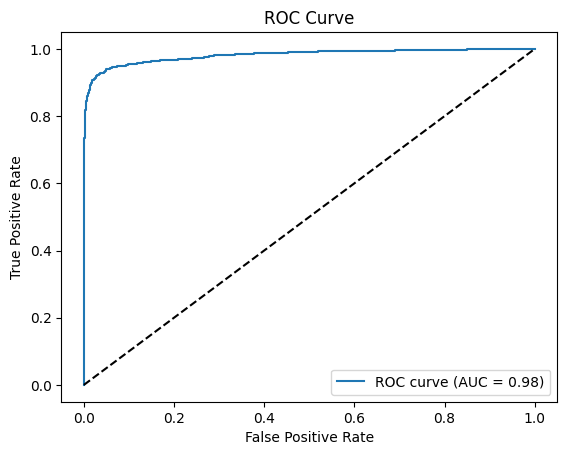

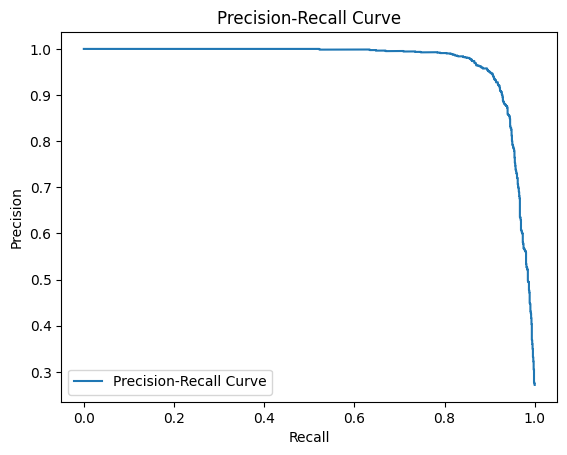

In [ ]:
#Resnet34
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from sklearn.utils import class_weight
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve, precision_recall_curve, auc
import numpy as np
import matplotlib.pyplot as plt

# === 1. Configurações Gerais ===
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
batch_size = 32
num_classes = 2
num_epochs = 50
data_dir = "/content/drive/MyDrive/RESULTADOS/MODELO_VGG16/nuclei_images_224_padding"

# === 2. Transforms (Sem Data Augmentation) ===
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

# === 3. Datasets ===
train_dataset = datasets.ImageFolder(root=f"{data_dir}/train", transform=transform)
val_dataset = datasets.ImageFolder(root=f"{data_dir}/val", transform=transform)
test_dataset = datasets.ImageFolder(root=f"{data_dir}/test", transform=transform)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

class_names = train_dataset.classes
print("Classes:", class_names)

# === 4. Calcular Pesos de Classe ===
train_labels = [label for _, label in train_dataset]
weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)
class_weights = torch.tensor(weights, dtype=torch.float).to(device)
print("Class Weights:", class_weights)

# === 5. Modelo ResNet34 ===
model = models.resnet34(weights=None)
model.fc = nn.Linear(model.fc.in_features, num_classes)
model = model.to(device)

# === 6. Loss, Optimizer e Callbacks Manuais ===
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(model.parameters(), lr=1e-4)

best_val_loss = np.inf
patience = 5
counter = 0

train_loss_hist, val_loss_hist = [], []
train_acc_hist, val_acc_hist = [], []

# === 7. Treinamento + Early Stopping ===
for epoch in range(num_epochs):
    model.train()
    running_loss, running_correct = 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        _, preds = torch.max(outputs, 1)
        running_loss += loss.item() * images.size(0)
        running_correct += (preds == labels).sum().item()

    train_loss = running_loss / len(train_dataset)
    train_acc = running_correct / len(train_dataset)

    # Validação
    model.eval()
    val_loss, val_correct = 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            val_correct += (preds == labels).sum().item()

    val_loss = val_loss / len(val_dataset)
    val_acc = val_correct / len(val_dataset)

    train_loss_hist.append(train_loss)
    val_loss_hist.append(val_loss)
    train_acc_hist.append(train_acc)
    val_acc_hist.append(val_acc)

    print(f"Epoch {epoch+1}: Train Loss={train_loss:.4f}, Train Acc={train_acc:.4f}, Val Loss={val_loss:.4f}, Val Acc={val_acc:.4f}")

    # Early Stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), '/content/drive/MyDrive/RESULTADOS/MODELO_RESNET34/best_resnet34_dash.pth')

        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping triggered.")
            break

# === SALVAR MODELO COMPLETO (estrutura + pesos) ===
import os
os.makedirs('/content/drive/MyDrive/RESULTADOS/MODELO_RESNET34', exist_ok=True)
torch.save(model, '/content/drive/MyDrive/RESULTADOS/MODELO_RESNET34/modelo_resnet34_completo_2.pth')

# === 8. Avaliação Final no Teste (Validação Cega) ===
model.load_state_dict(torch.load('/content/drive/MyDrive/RESULTADOS/MODELO_RESNET34/best_resnet34_dash.pth'))
model.eval()

y_true, y_probs = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)[:, 1]  # Probabilidade da classe 1
        y_probs.extend(probs.cpu().numpy())
        y_true.extend(labels.cpu().numpy())

y_pred = [1 if p >= 0.5 else 0 for p in y_probs]

print("\nConfusion Matrix:\n", confusion_matrix(y_true, y_pred))
print("\nClassification Report:\n", classification_report(y_true, y_pred, target_names=class_names))

# === 9. ROC e PR Curve ===
fpr, tpr, _ = roc_curve(y_true, y_probs)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()

precision, recall, _ = precision_recall_curve(y_true, y_probs)
plt.figure()
plt.plot(recall, precision, label='Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()


In [ ]:
import plotly.graph_objs as go
import plotly.figure_factory as ff
from sklearn.metrics import roc_curve, auc, precision_recall_curve
import numpy as np

# === Gráfico de Loss ===
fig_loss = go.Figure()
fig_loss.add_trace(go.Scatter(y=train_loss_hist, mode='lines', name='Training Loss'))
fig_loss.add_trace(go.Scatter(y=val_loss_hist, mode='lines', name='Validation Loss'))
fig_loss.update_layout(title='Perdas de Treinamento e Validação', xaxis_title='Épocas', yaxis_title='Loss')
fig_loss.show()

# === Gráfico de Accuracy ===
fig_acc = go.Figure()
fig_acc.add_trace(go.Scatter(y=train_acc_hist, mode='lines', name='Training Accuracy'))
fig_acc.add_trace(go.Scatter(y=val_acc_hist, mode='lines', name='Validation Accuracy'))
fig_acc.update_layout(title='Acurácia de Treinamento e Validação', xaxis_title='Épocas', yaxis_title='Acurácia')
fig_acc.show()

# === Matriz de Confusão ===
cm = confusion_matrix(y_true, y_pred)
x_labels = class_names  # ['abnormal', 'normal'] por exemplo
fig_cm = ff.create_annotated_heatmap(
    z=cm,
    x=x_labels,
    y=x_labels,
    colorscale='Blues',
    showscale=True
)
fig_cm.update_layout(title='Matriz de Confusão', xaxis_title='Previsto', yaxis_title='Real')
fig_cm.show()

# === Curva ROC ===
fpr, tpr, _ = roc_curve(y_true, y_probs)  # y_probs já é a probabilidade da classe positiva (classe 1)
roc_auc = auc(fpr, tpr)

fig_roc = go.Figure()
fig_roc.add_trace(go.Scatter(x=fpr, y=tpr, mode='lines', name=f'ROC Curve (AUC={roc_auc:.2f})'))
fig_roc.add_trace(go.Scatter(x=[0, 1], y=[0, 1], mode='lines', line=dict(dash='dash'), name='Random'))
fig_roc.update_layout(title='Curva ROC', xaxis_title='Taxa de Falso Positivo', yaxis_title='Taxa de Verdadeiro Positivo')
fig_roc.show()

# === Precision-Recall Curve ===
precision, recall, _ = precision_recall_curve(y_true, y_probs)

fig_pr = go.Figure()
fig_pr.add_trace(go.Scatter(x=recall, y=precision, mode='lines', name='Curva de Precision-Recall'))
fig_pr.update_layout(title='Curva de Precision-Recall', xaxis_title='Recall', yaxis_title='Precisão')
fig_pr.show()


You can upload files from your local machine to your Colab environment using the following code:

After uploading the files, make sure they are in the correct directory relative to your notebook, or update the import paths in your code. If the helper files are part of a library, try installing it using `!pip install your_library_name`.

# VGG16

In [ ]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
import keras
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from keras.models import Sequential
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Seed
tf.random.set_seed(0)

# Definição do modelo VGG16 Custom
model = keras.Sequential()

# Block 1
model.add(Conv2D(64, (3, 3), padding='same', activation='relu', input_shape=(224, 224, 3)))
model.add(Conv2D(64, (3, 3), padding='same', activation='relu'))
model.add(MaxPooling2D((2, 2), strides=(2, 2)))

# Block 2
model.add(Conv2D(128, (3, 3), padding='same', activation='relu'))
model.add(Conv2D(128, (3, 3), padding='same', activation='relu'))
model.add(MaxPooling2D((2, 2), strides=(2, 2)))

# Block 3
model.add(Conv2D(256, (3, 3), padding='same', activation='relu'))
model.add(Conv2D(256, (3, 3), padding='same', activation='relu'))
model.add(Conv2D(256, (3, 3), padding='same', activation='relu'))
model.add(MaxPooling2D((2, 2), strides=(2, 2)))

# Block 4
model.add(Conv2D(512, (3, 3), padding='same', activation='relu'))
model.add(Conv2D(512, (3, 3), padding='same', activation='relu'))
model.add(Conv2D(512, (3, 3), padding='same', activation='relu'))
model.add(MaxPooling2D((2, 2), strides=(2, 2)))

# Block 5
model.add(Conv2D(512, (3, 3), padding='same', activation='relu'))
model.add(Conv2D(512, (3, 3), padding='same', activation='relu'))
model.add(Conv2D(512, (3, 3), padding='same', activation='relu'))
model.add(MaxPooling2D((2, 2), strides=(2, 2)))

# Top
model.add(Flatten())
model.add(Dense(512, activation='relu'))
model.add(Dense(512, activation='relu'))
model.add(Dense(2, activation='softmax'))

# Compilação
optimizer = Adam(learning_rate=1e-4)
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

# Data Generators (sem augmentation)
train_dir = "/content/drive/MyDrive/RESULTADOS/MODELOS/MODELO_VGG16/nuclei_images_224_padding/train"
val_dir = "/content/drive/MyDrive/RESULTADOS/MODELOS/MODELO_VGG16/nuclei_images_224_padding/val"
test_dir = "/content/drive/MyDrive/RESULTADOS/MODELOS/MODELO_VGG16/nuclei_images_224_padding/test"

train_datagen = ImageDataGenerator(rescale=1./255)
val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

batch_size = 32

train_generator = train_datagen.flow_from_directory(
    train_dir, target_size=(224,224), batch_size=batch_size, class_mode='categorical'
)

val_generator = val_datagen.flow_from_directory(
    val_dir, target_size=(224,224), batch_size=batch_size, class_mode='categorical'
)

test_generator = test_datagen.flow_from_directory(
    test_dir, target_size=(224,224), batch_size=batch_size, class_mode='categorical', shuffle=False
)

# Callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-7)



# Ajustes

from sklearn.utils import class_weight
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# === 1. Confirmar classes ===
print(train_generator.class_indices)
# Saída: {'abnormal': 0, 'normal': 1}

# === 2. Calcular os pesos de classe ===
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)
class_weights = dict(enumerate(class_weights))
print("Pesos de classe:", class_weights)

# === 3. Treinar com class_weight ===
history = model.fit(
    train_generator,
    epochs=50,
    validation_data=val_generator,
    callbacks=[early_stop, reduce_lr],
    class_weight=class_weights
)


model.save('/content/drive/MyDrive/RESULTADOS/MODELOS/MODELO_VGG16/modelo_vgg16_out_custom.h5')

# === 4. Avaliação no Teste ===
test_loss, test_acc = model.evaluate(test_generator)
print(f"Teste - Loss: {test_loss:.4f}, Accuracy: {test_acc:.4f}")

# === 5. Avaliação na validação escondida ===
val_loss, val_acc = model.evaluate(val_generator)
print(f"Validação escondida - Loss: {val_loss:.4f}, Accuracy: {val_acc:.4f}")

# === 6. Predições e Avaliação por Classe ===
y_true = test_generator.classes
y_pred_probs = model.predict(test_generator)
y_pred = np.argmax(y_pred_probs, axis=1)

# Matriz de Confusão
print("\nMatriz de Confusão:")
print(confusion_matrix(y_true, y_pred))

# Relatório por Classe
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=list(test_generator.class_indices.keys())))


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Found 22387 images belonging to 2 classes.
Found 4052 images belonging to 2 classes.
Found 4586 images belonging to 2 classes.
{'abnormal': 0, 'normal': 1}
Pesos de classe: {0: np.float64(0.6830719472752792), 1: np.float64(1.8655833333333334)}


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
700/700 ━━━━━━━━━━━━━━━━━━━━ 2603s 4s/step - accuracy: 0.6684 - loss: 0.5664 - val_accuracy: 0.8904 - val_loss: 0.2893 - learning_rate: 1.0000e-04
Epoch 2/50
700/700 ━━━━━━━━━━━━━━━━━━━━ 354s 506ms/step - accuracy: 0.8818 - loss: 0.3448 - val_accuracy: 0.9149 - val_loss: 0.2453 - learning_rate: 1.0000e-04
Epoch 3/50
700/700 ━━━━━━━━━━━━━━━━━━━━ 353s 505ms/step - accuracy: 0.9155 - loss: 0.2724 - val_accuracy: 0.9171 - val_loss: 0.2367 - learning_rate: 1.0000e-04
Epoch 4/50
700/700 ━━━━━━━━━━━━━━━━━━━━ 353s 504ms/step - accuracy: 0.9189 - loss: 0.2680 - val_accuracy: 0.9181 - val_loss: 0.2338 - learning_rate: 1.0000e-04
Epoch 5/50
700/700 ━━━━━━━━━━━━━━━━━━━━ 351s 502ms/step - accuracy: 0.9237 - loss: 0.2429 - val_accuracy: 0.9237 - val_loss: 0.2373 - learning_rate: 1.0000e-04
Epoch 6/50
700/700 ━━━━━━━━━━━━━━━━━━━━ 351s 501ms/step - accuracy: 0.9261 - loss: 0.2347 - val_accuracy: 0.9040 - val_loss: 0.2806 - learning_rate: 1.0000e-04
Epoch 7/50
700/700 ━━━━━━━━━━━━━━━━━━━━ 35

144/144 ━━━━━━━━━━━━━━━━━━━━ 1023s 7s/step - accuracy: 0.9687 - loss: 0.1194
Teste - Loss: 0.1384, Accuracy: 0.9566
127/127 ━━━━━━━━━━━━━━━━━━━━ 19s 147ms/step - accuracy: 0.9317 - loss: 0.2148
Validação escondida - Loss: 0.2065, Accuracy: 0.9356
144/144 ━━━━━━━━━━━━━━━━━━━━ 23s 153ms/step

Matriz de Confusão:
[[3266   74]
 [ 125 1121]]

Classification Report:
              precision    recall  f1-score   support

    abnormal       0.96      0.98      0.97      3340
      normal       0.94      0.90      0.92      1246

    accuracy                           0.96      4586
   macro avg       0.95      0.94      0.94      4586
weighted avg       0.96      0.96      0.96      4586



In [ ]:
# Apresentar resultados

import plotly.graph_objs as go
import plotly.figure_factory as ff
from sklearn.metrics import roc_curve, auc, precision_recall_curve
from sklearn.preprocessing import label_binarize
import numpy as np

# === 8. Gráfico de Loss ===
fig_loss = go.Figure()
fig_loss.add_trace(go.Scatter(y=history.history['loss'], mode='lines', name='Training Loss'))
fig_loss.add_trace(go.Scatter(y=history.history['val_loss'], mode='lines', name='Validation Loss'))
fig_loss.update_layout(title='Perdas de Treinamento e Validação', xaxis_title='Épocas', yaxis_title='Loss')
fig_loss.show()

# === 9. Gráfico de Accuracy ===
fig_acc = go.Figure()
fig_acc.add_trace(go.Scatter(y=history.history['accuracy'], mode='lines', name='Training Accuracy'))
fig_acc.add_trace(go.Scatter(y=history.history['val_accuracy'], mode='lines', name='Validation Accuracy'))
fig_acc.update_layout(title='Acurácia de Treinamento e Validação', xaxis_title='Épocas', yaxis_title='Acurácia')
fig_acc.show()

# === 10. Matriz de Confusão ===
cm = confusion_matrix(y_true, y_pred)
x_labels = list(test_generator.class_indices.keys())
fig_cm = ff.create_annotated_heatmap(
    z=cm,
    x=x_labels,
    y=x_labels,
    colorscale='Blues',
    showscale=True
)
fig_cm.update_layout(title='Matriz de Confusão', xaxis_title='Previsto', yaxis_title='Real')
fig_cm.show()

# === 11. Curva ROC ===
# Use y_true directly and the probabilities of the positive class (class 1)
fpr, tpr, _ = roc_curve(y_true, y_pred_probs[:, 1])
roc_auc = auc(fpr, tpr)

fig_roc = go.Figure()
fig_roc.add_trace(go.Scatter(x=fpr, y=tpr, mode='lines', name=f'ROC Curve (AUC={roc_auc:.2f})'))
fig_roc.add_trace(go.Scatter(x=[0, 1], y=[0, 1], mode='lines', line=dict(dash='dash'), name='Random'))
fig_roc.update_layout(title='Curva ROC', xaxis_title='Taxa de Falso Positivo', yaxis_title='Taxa de Verdadeiro Positivo')
fig_roc.show()

# === 12. Precision-Recall Curve ===
# Use y_true directly and the probabilities of the positive class (class 1)
precision, recall, _ = precision_recall_curve(y_true, y_pred_probs[:, 1])

fig_pr = go.Figure()
fig_pr.add_trace(go.Scatter(x=recall, y=precision, mode='lines', name='Curva de Precision-Recall'))
fig_pr.update_layout(title='Curva de Precision-Recall', xaxis_title='Recall', yaxis_title='Precisão')
fig_pr.show()